# **Exercise 1: Deep Learning vs. Traditional Machine Learning**

# ** Traditional Machine Learning**

*   Feature Engineering: Features must be manually selected or engineered by humans (domain experts decide what matters).
*   Data Processing: Works well with small to medium-sized datasets; performance drops with huge, unstructured data.
*   Scalability: Limited scalability — adding more data doesn’t always improve performance.
*   Pattern Discovery: Good at learning simple and linear patterns.
*   Computational Requirements: Can run efficiently on CPUs; relatively light on hardware.

# **VS**

# **Deep Learning **

*   Feature Engineering: The model automatically learns relevant features during training — no manual selection needed.
*   Data Processing: Requires massive datasets to generalize well and learn complex relationships.
*   Scalability: Highly scalable — performance usually improves as data and computational power increase.
*   Pattern Discovery: Excellent at discovering deep, non-linear, and hierarchical patterns through multiple layers.
*   Computational Requirements: Requires GPUs/TPUs for parallel processing and faster training; computationally expensive.

Traditional ML is better for: Credit risk prediction in banking.
→ It involves structured, tabular data (income, credit score, loan history).
Logistic Regression or Random Forest models perform well, are interpretable, and don’t need massive datasets.

Deep Learning is better for: Facial recognition in security systems.
→ It processes high-dimensional, unstructured image data. Convolutional Neural Networks (CNNs) learn spatial hierarchies automatically — something traditional ML can’t handle effectively.

Deep learning models outperform traditional ML in unstructured data (images, text, audio, video) because they can automatically learn hierarchical representations — low-level to high-level features — without manual engineering.
For example, in image recognition, early layers detect edges, mid-layers detect shapes, and deeper layers detect objects.
This automatic feature discovery allows deep learning to make sense of raw data formats that traditional algorithms struggle to interpret.

# **Exercise 2: Artificial Neural Networks (ANNs)**

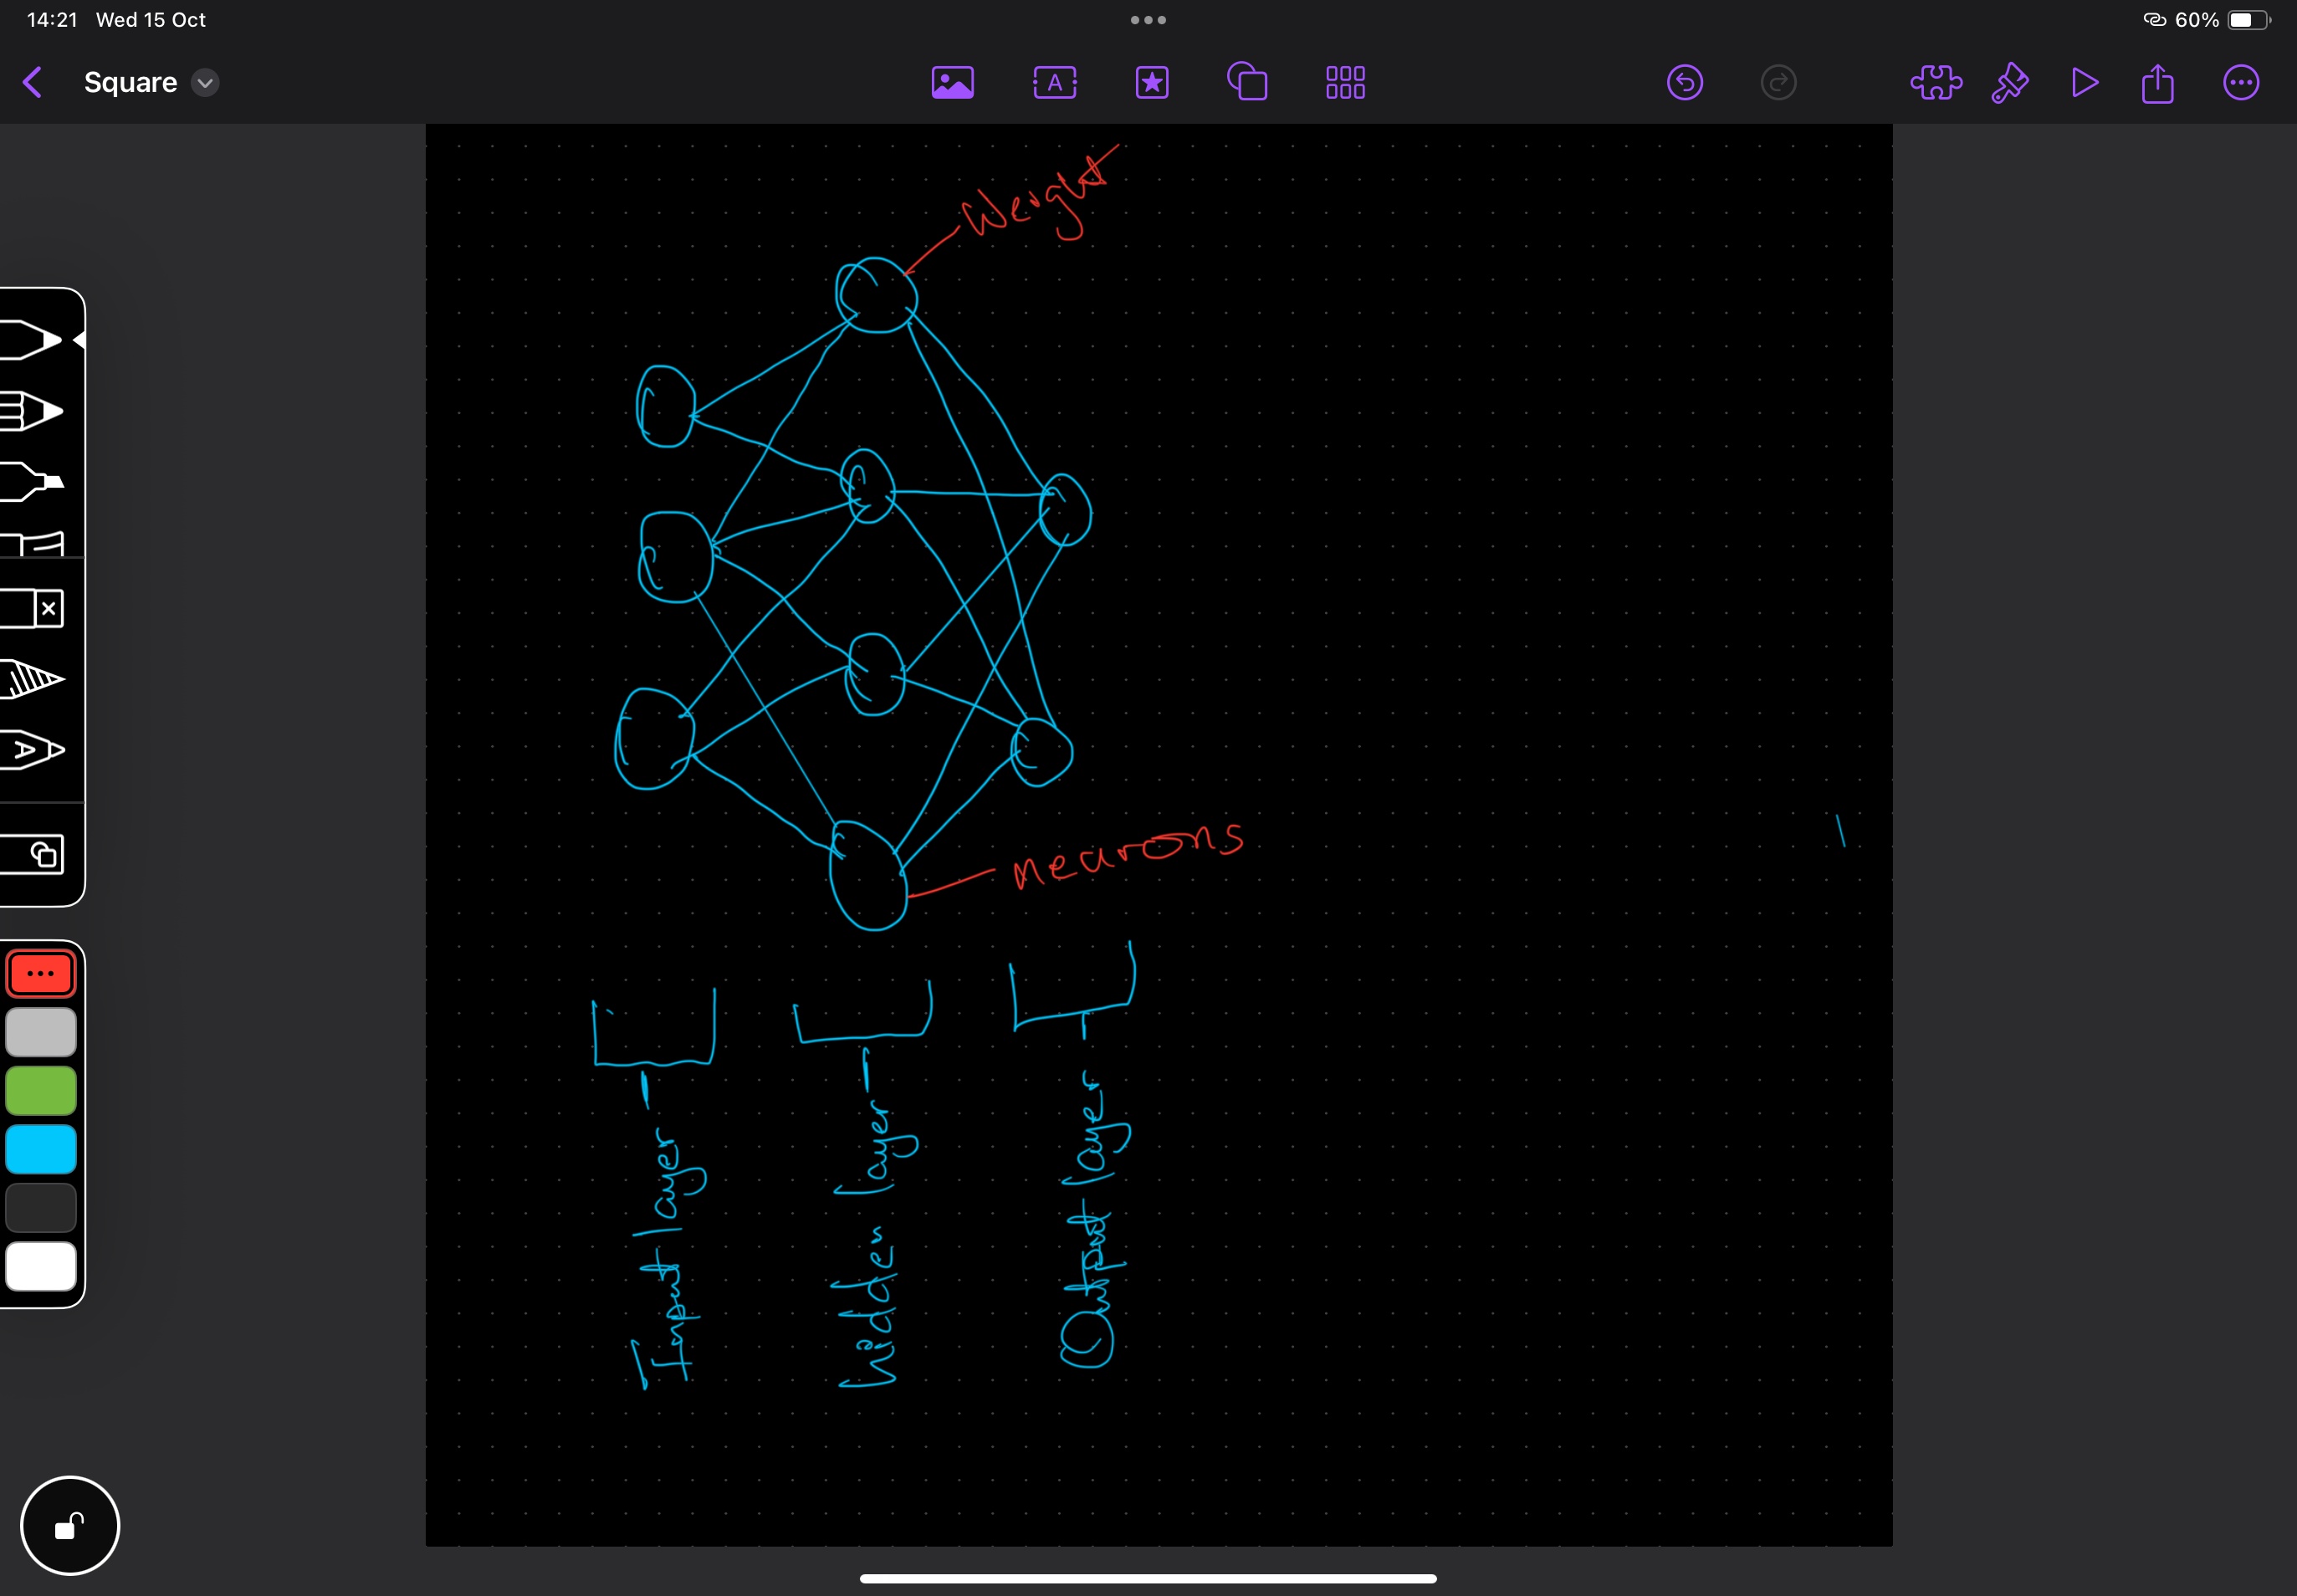


Information Flow in an ANN:
Data enters through the input layer, each input is multiplied by a weight, and a bias is added.
These values pass through the hidden layer, where the activation function decides which signals move forward.
Finally, the output layer combines the signals to make a prediction (like classifying an image or predicting a value).

In short — inputs → weighted sum → activation → output.

# **Exercise 3: Creating the Dataset and Visualizing the Data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

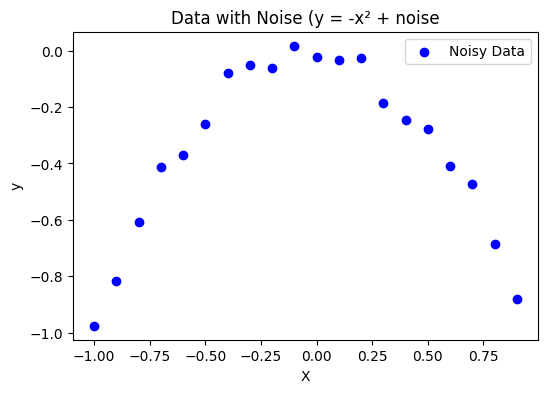

In [ ]:
# Creating dataset with noise
np.random.seed(42)
X = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x)) # added noise over here

plt.figure(figsize=(6,4))
plt.scatter(X, y, color="blue", label="Noisy Data")
plt.title("Data with Noise (y = -x² + noise")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
X_train, y_train = x[:12], y[:12]
X_test, y_test = x[12:], y[12:]

# **Exercise 4: Fitting Polynomial Models of Different Degrees**



In [ ]:
 # Fit a polynomial of given degree to the TRAIN data

def polynomial_fit(degree, X_train, y_trainn):
  coeffs = np.polyfit(X_train, y_train, degree)
  return np.poly1d(coeffs)

# Plot train/test scatter + fitted curve, and report MSEs

def plot_polyfit(degree, X_train, y_train, X_test, y_test, X_full=None):
  p = polynomial_fit(degree, X_train, y_train)

  # smooth curve across the full x-range
  if X_full is None:
    X_min = min(X_train.min(), X_test.min())
    X_max = max(X_train.max(), X_test.max())
    X_full = np.linnspace(X_min, X_max, 400)
  y_full = p(X_full)

  # predictions & MSE
  y_pred_train = p(X_train)
  y_pred_test = p(X_test)
  mse_train = mean_squared_error(y_train, y_pred_train)
  mse_test = mean_squared_error(y_test, y_pred_test)

  # plotting
  plt.scatter(X_train, y_train, color="tab:blue", label="Train", alpha=0.8)
  plt.scatter(X_test, y_test, color="tab:orange", label="Test", alpha=0.8)
  plt.plot(X_full, y_full, color="black", lw=2, label=f"Degree {degree} fit")
  plt.title(f"Degree {degree} | MSE (train)={mse_train:.4f} MSE (test)={mse_test:.4f}")
  plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)
  plt.show()

# Visualise degree 1, 7, and 11
  for d in [1, 7, 11]:
    plot_polyfit(d, X_train, y_train, X_test, y_test)


# **Exercise 5: Cross-Validation to Find the Optimal Degree**


Degrees: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Train RMSE: [np.float64(0.1218), np.float64(0.0314), np.float64(0.0313), np.float64(0.0313), np.float64(0.0312), np.float64(0.0304), np.float64(0.0264), np.float64(0.0248), np.float64(0.0045), np.float64(0.0031), np.float64(0.0)]
Test  RMSE: [np.float64(1.0606), np.float64(0.1099), np.float64(0.1855), np.float64(0.0567), np.float64(0.9242), np.float64(24.0424), np.float64(219.8616), np.float64(639.3235), np.float64(15097.0035), np.float64(751.5868), np.float64(157315.6177)]

✅ Best degree by test RMSE: 4


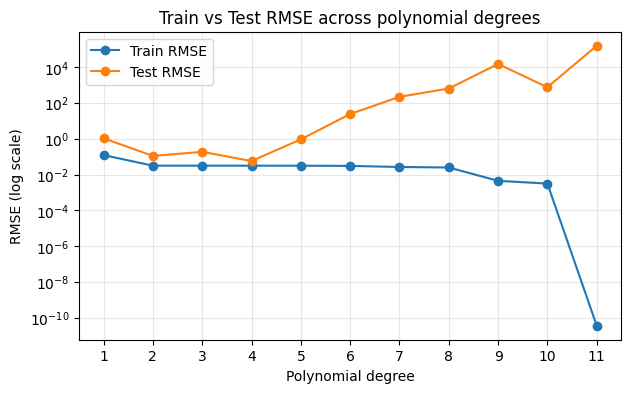

In [ ]:
# Helper: fit degree-d polynomial on TRAIN, return callable p(x)
def fit_poly(degree, X, y):
    coeffs = np.polyfit(X.ravel(), y, degree)
    return np.poly1d(coeffs)

degrees = range(1, 12)  # 1..11 inclusive
rmse_train, rmse_test = [], []

for d in degrees:
    p = fit_poly(d, X_train, y_train)

    # predictions
    yhat_tr = p(X_train)
    yhat_te = p(X_test)

    # RMSE
    rmse_tr = np.sqrt(mean_squared_error(y_train, yhat_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  yhat_te))

    rmse_train.append(rmse_tr)
    rmse_test.append(rmse_te)

# Find best degree by lowest test RMSE
best_idx = int(np.argmin(rmse_test))
best_degree = list(degrees)[best_idx]

print("Degrees:", list(degrees))
print("Train RMSE:", [round(v, 4) for v in rmse_train])
print("Test  RMSE:", [round(v, 4) for v in rmse_test])
print(f"\n Best degree by test RMSE: {best_degree}")

# Plot
plt.figure(figsize=(7,4))
plt.plot(degrees, rmse_train, marker="o", label="Train RMSE")
plt.plot(degrees, rmse_test,  marker="o", label="Test RMSE")
plt.yscale("log")  # requested log scale for y-axis
plt.xticks(degrees)
plt.xlabel("Polynomial degree")
plt.ylabel("RMSE (log scale)")
plt.title("Train vs Test RMSE across polynomial degrees")
plt.grid(alpha=0.3)
plt.legend()
plt.show()